<a href="https://colab.research.google.com/github/hasinduW/SE4050-waste-classification-4models/blob/ResNet50/DL_Waste_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, ResNet50

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [10]:
# STEP 1 — Paths & Config
DATA_DIR = '/content/drive/MyDrive/Waste Images'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
EPOCHS     = 8          # keep 5–10 for fast runs
LR         = 1e-4
SEED       = 42
tf.keras.utils.set_random_seed(SEED)

assert os.path.isdir(DATA_DIR), f"Folder not found: {DATA_DIR}"


In [13]:
# STEP 2 — Data Generators (Preprocess & Aug)
# a) Plain preprocessing (for Baseline)
base_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

# b) With augmentation (for Aug CNN & MobileNetV2)
aug_gen = ImageDataGenerator(
    rescale=1./255, validation_split=VAL_SPLIT,
    rotation_range=25, width_shift_range=0.2, height_shift_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

train_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

class_names = list(train_base.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)


Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']


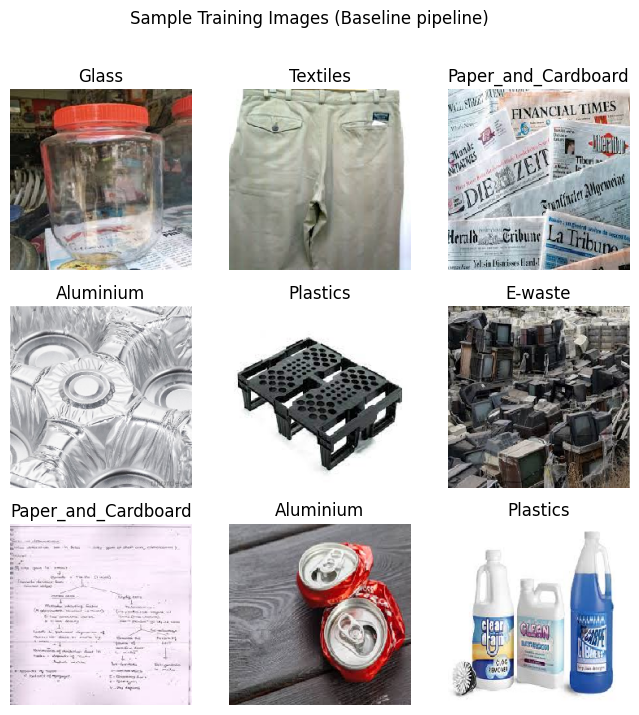

In [14]:

# STEP 3 — Peek some training data
x_batch, y_batch = next(train_base)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[np.argmax(y_batch[i])])
    plt.axis('off')
plt.suptitle("Sample Training Images (Baseline pipeline)")
plt.show()


In [15]:
# Utilities — plotting & evaluation helpers
def plot_history(history, title=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

def eval_and_report(model, val_gen, title=""):
    # Evaluate
    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f"{title} — Val Accuracy: {acc*100:.2f}% | Val Loss: {loss:.4f}")
    # Predict
    preds = model.predict(val_gen, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = val_gen.classes
    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7,6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    plt.title(f'Confusion Matrix — {title}')
    plt.show()
    # Classif report
    print(classification_report(true_labels, pred_labels, target_names=class_names))

In [16]:
# STEP 4 — Callbacks (ES, LR scheduler, CKPT)

ckpt_dir = '/content/drive/MyDrive/Waste_Images/checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

def common_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(os.path.join(ckpt_dir, f'best_{tag}.keras'),
                        monitor='val_loss', save_best_only=True, verbose=1)
    ]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,985 (84.87 MB)

 Trainable params: 22,246,985 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.2361 - loss: 2.0644
Epoch 1: val_loss improved from inf to 1.81530, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 60s 252ms/step - accuracy: 0.2364 - loss: 2.0638 - val_accuracy: 0.3350 - val_loss: 1.8153 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3733 - loss: 1.7458
Epoch 2: val_loss improved from 1.81530 to 1.73543, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 48s 232ms/step - accuracy: 0.3733 - loss: 1.7458 - val_accuracy: 0.3471 - val_loss: 1.7354 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.4173 - loss: 1.6286
Epoch 3: val_loss improved from 1.73543 to 1.67347, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━

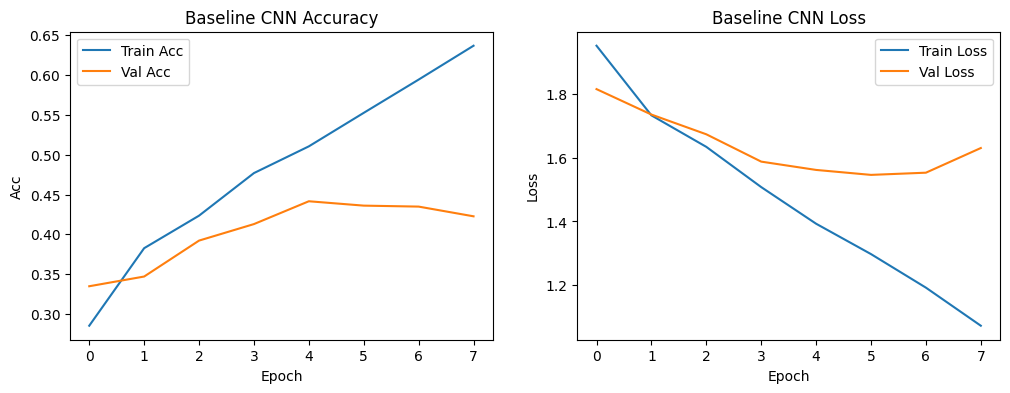

Baseline CNN — Val Accuracy: 43.61% | Val Loss: 1.5460


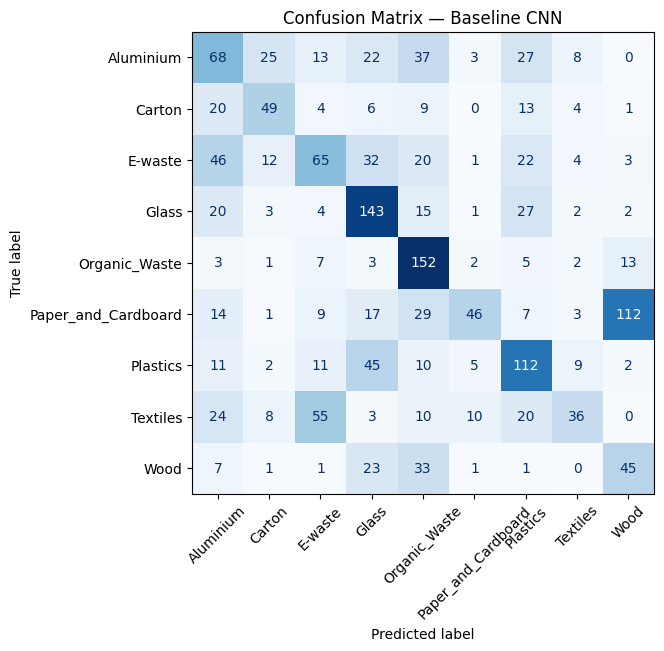

                     precision    recall  f1-score   support

          Aluminium       0.32      0.33      0.33       203
             Carton       0.48      0.46      0.47       106
            E-waste       0.38      0.32      0.35       205
              Glass       0.49      0.66      0.56       217
      Organic_Waste       0.48      0.81      0.60       188
Paper_and_Cardboard       0.67      0.19      0.30       238
           Plastics       0.48      0.54      0.51       207
           Textiles       0.53      0.22      0.31       166
               Wood       0.25      0.40      0.31       112

           accuracy                           0.44      1642
          macro avg       0.45      0.44      0.42      1642
       weighted avg       0.47      0.44      0.42      1642



In [20]:
# STEP 5 — Model 1: Baseline CNN (from scratch)
def build_baseline_cnn(input_shape=(224,224,3), classes=9):
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline = build_baseline_cnn(classes=num_classes)
baseline.summary()

hist_base = baseline.fit(
    train_base, epochs=EPOCHS, validation_data=val_base,
    callbacks=common_callbacks('baseline_cnn'), verbose=1
)
plot_history(hist_base, "Baseline CNN")
eval_and_report(baseline, val_base, "Baseline CNN")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.2164 - loss: 2.0858
Epoch 1: val_loss improved from inf to 1.85179, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 656ms/step - accuracy: 0.2166 - loss: 2.0853 - val_accuracy: 0.3228 - val_loss: 1.8518 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.3293 - loss: 1.8435
Epoch 2: val_loss improved from 1.85179 to 1.79593, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 683ms/step - accuracy: 0.3293 - loss: 1.8435 - val_accuracy: 0.3350 - val_loss: 1.7959 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.3555 - loss: 1.7838
Epoch 3: val_loss improved from 1.79593 to 1.77283, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 679ms/

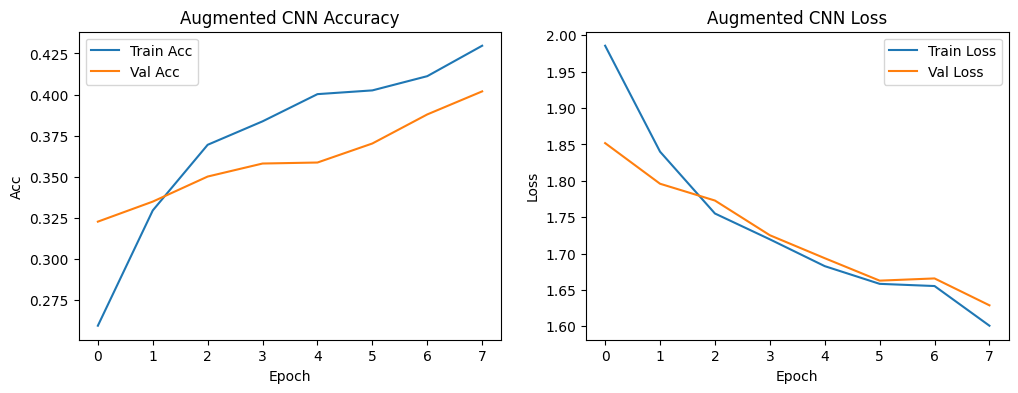

Augmented CNN — Val Accuracy: 40.07% | Val Loss: 1.6239


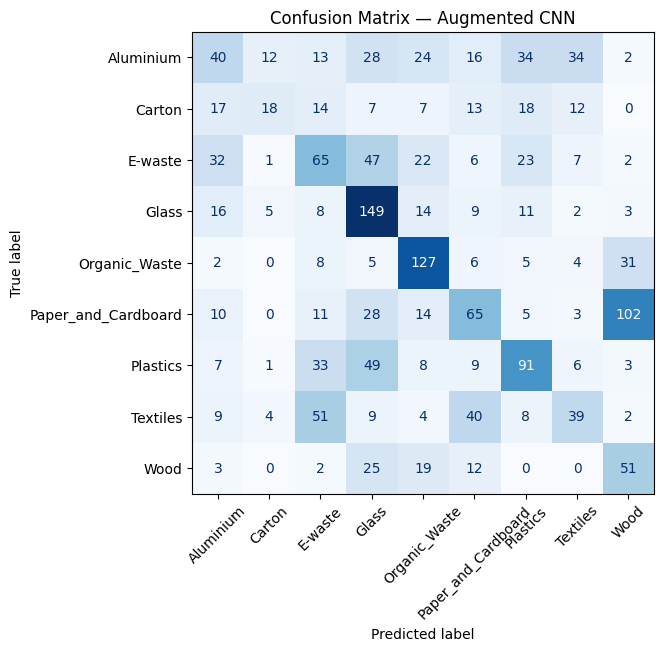

                     precision    recall  f1-score   support

          Aluminium       0.29      0.20      0.24       203
             Carton       0.44      0.17      0.24       106
            E-waste       0.32      0.32      0.32       205
              Glass       0.43      0.69      0.53       217
      Organic_Waste       0.53      0.68      0.59       188
Paper_and_Cardboard       0.37      0.27      0.31       238
           Plastics       0.47      0.44      0.45       207
           Textiles       0.36      0.23      0.29       166
               Wood       0.26      0.46      0.33       112

           accuracy                           0.39      1642
          macro avg       0.39      0.38      0.37      1642
       weighted avg       0.39      0.39      0.38      1642



In [21]:
# STEP 6 — Model 2: CNN with Data Augmentation
aug_cnn = build_baseline_cnn(classes=num_classes)
hist_aug = aug_cnn.fit(
    train_aug, epochs=EPOCHS, validation_data=val_aug,
    callbacks=common_callbacks('aug_cnn'), verbose=1
)
plot_history(hist_aug, "Augmented CNN")
eval_and_report(aug_cnn, val_aug, "Augmented CNN")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.3076 - loss: 1.9744
Epoch 1: val_loss improved from inf to 0.95811, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 180s 779ms/step - accuracy: 0.3083 - loss: 1.9725 - val_accuracy: 0.7235 - val_loss: 0.9581 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.6768 - loss: 0.9661
Epoch 2: val_loss improved from 0.95811 to 0.77239, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 131s 636ms/step - accuracy: 0.6769 - loss: 0.9657 - val_accuracy: 0.7600 - val_loss: 0.7724 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.7465 - loss: 0.7621
Epoch 3: val_loss improved from 0.77239 to 0.68716, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━

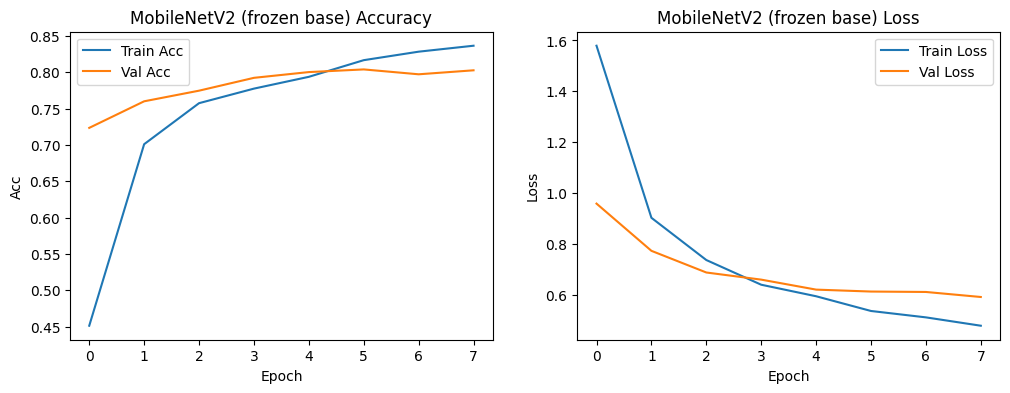

MobileNetV2 — Val Accuracy: 80.27% | Val Loss: 0.6061


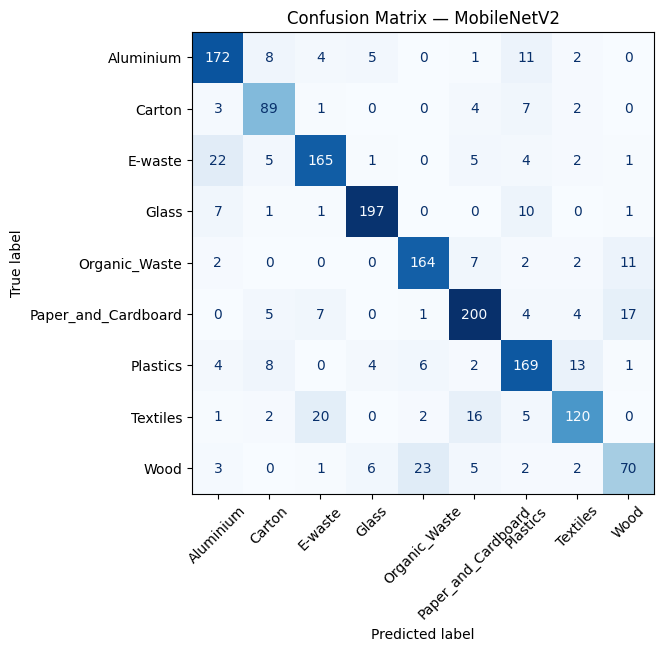

                     precision    recall  f1-score   support

          Aluminium       0.80      0.85      0.82       203
             Carton       0.75      0.84      0.79       106
            E-waste       0.83      0.80      0.82       205
              Glass       0.92      0.91      0.92       217
      Organic_Waste       0.84      0.87      0.85       188
Paper_and_Cardboard       0.83      0.84      0.84       238
           Plastics       0.79      0.82      0.80       207
           Textiles       0.82      0.72      0.77       166
               Wood       0.69      0.62      0.66       112

           accuracy                           0.82      1642
          macro avg       0.81      0.81      0.81      1642
       weighted avg       0.82      0.82      0.82      1642



In [24]:
# STEP 7 — Model 3: Transfer Learning (MobileNetV2)
base_mnet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
for layer in base_mnet.layers:
    layer.trainable = False  # freeze base for fast, stable training

mnet = Sequential([
    base_mnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
mnet.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
mnet.summary()

hist_mnet = mnet.fit(
    train_aug, epochs=EPOCHS, validation_data=val_aug,
    callbacks=common_callbacks('mobilenetv2'), verbose=1
)
plot_history(hist_mnet, "MobileNetV2 (frozen base)")
eval_and_report(mnet, val_aug, "MobileNetV2")


Epoch 1/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.7239 - loss: 0.8235
Epoch 1: val_loss improved from inf to 0.63746, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 160s 700ms/step - accuracy: 0.7241 - loss: 0.8231 - val_accuracy: 0.7917 - val_loss: 0.6375 - learning_rate: 1.0000e-05
Epoch 2/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8000 - loss: 0.6055
Epoch 2: val_loss improved from 0.63746 to 0.63274, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 131s 634ms/step - accuracy: 0.8000 - loss: 0.6054 - val_accuracy: 0.7917 - val_loss: 0.6327 - learning_rate: 1.0000e-05
Epoch 3/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8106 - loss: 0.5630
Epoch 3: val_loss improved from 0.63274 to 0.60475, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2_finetune.keras
2

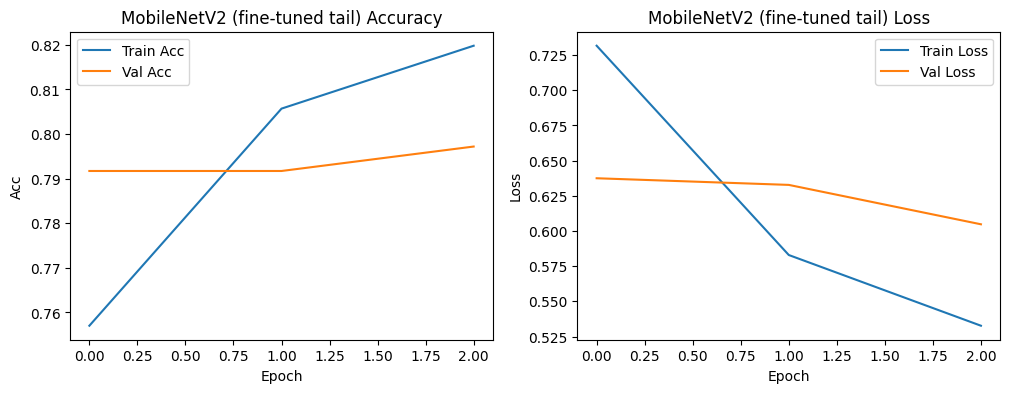

MobileNetV2 (fine-tuned) — Val Accuracy: 80.09% | Val Loss: 0.5896


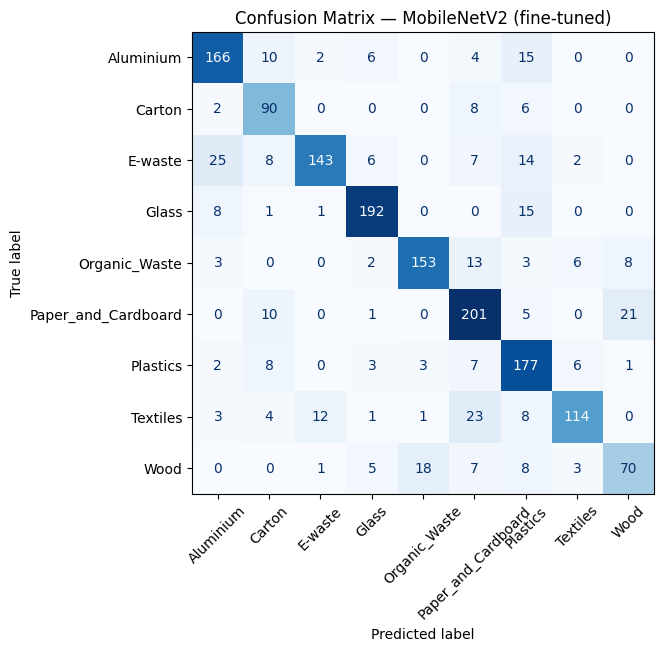

                     precision    recall  f1-score   support

          Aluminium       0.79      0.82      0.81       203
             Carton       0.69      0.85      0.76       106
            E-waste       0.90      0.70      0.79       205
              Glass       0.89      0.88      0.89       217
      Organic_Waste       0.87      0.81      0.84       188
Paper_and_Cardboard       0.74      0.84      0.79       238
           Plastics       0.71      0.86      0.77       207
           Textiles       0.87      0.69      0.77       166
               Wood       0.70      0.62      0.66       112

           accuracy                           0.80      1642
          macro avg       0.80      0.79      0.79      1642
       weighted avg       0.80      0.80      0.80      1642



In [25]:
# STEP 8 — (Optional) Fine-tune MobileNetV2 last blocks
# Unfreeze last N layers for a short fine-tune if you have time/GPU.
UNFREEZE_LAST = 20  # tune this if needed; keep small for 3-day plan

for layer in base_mnet.layers[-UNFREEZE_LAST:]:
    layer.trainable = True

mnet.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
hist_ft = mnet.fit(
    train_aug, epochs=3, validation_data=val_aug,
    callbacks=common_callbacks('mobilenetv2_finetune'), verbose=1
)
plot_history(hist_ft, "MobileNetV2 (fine-tuned tail)")
eval_and_report(mnet, val_aug, "MobileNetV2 (fine-tuned)")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1309 - loss: 2.3685 
Epoch 1: val_loss improved from inf to 2.11794, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 3137s 15s/step - accuracy: 0.1310 - loss: 2.3680 - val_accuracy: 0.1839 - val_loss: 2.1179 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.1791 - loss: 2.1289
Epoch 2: val_loss improved from 2.11794 to 2.09954, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 676ms/step - accuracy: 0.1791 - loss: 2.1289 - val_accuracy: 0.2034 - val_loss: 2.0995 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.2163 - loss: 2.0840
Epoch 3: val_loss improved from 2.09954 to 2.09823, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 679ms

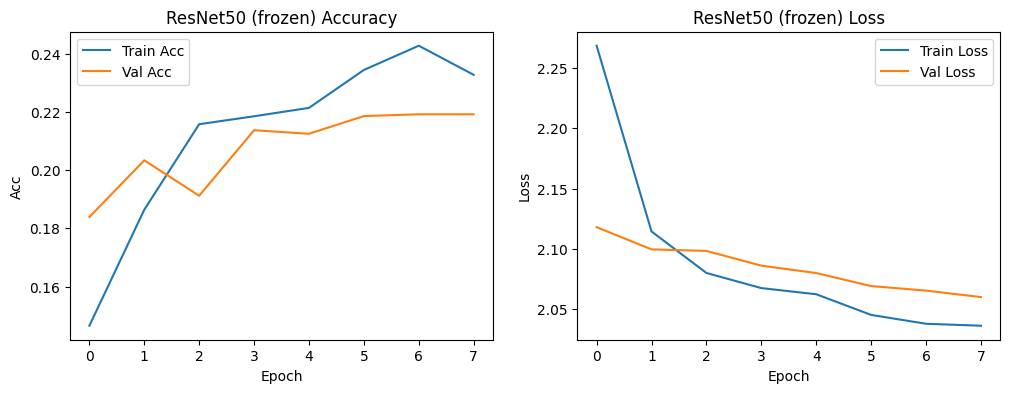

ResNet50 (frozen) — Val Accuracy: 21.19% | Val Loss: 2.0654


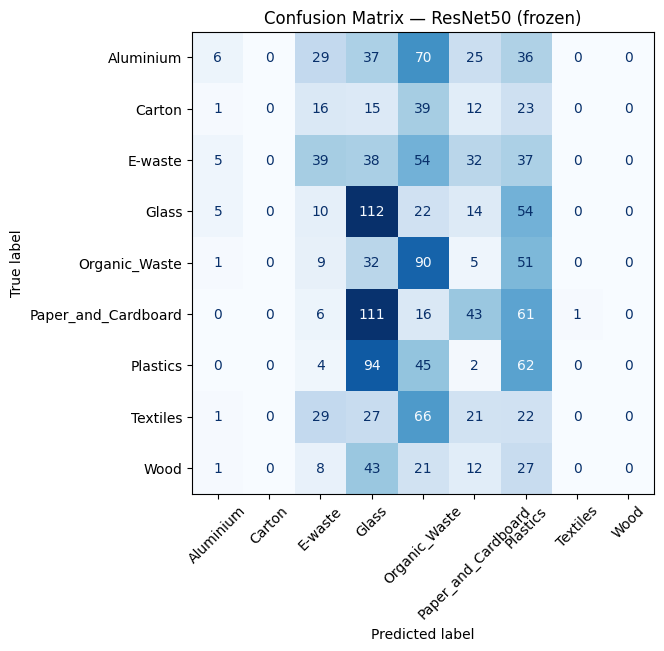

                     precision    recall  f1-score   support

          Aluminium       0.30      0.03      0.05       203
             Carton       0.00      0.00      0.00       106
            E-waste       0.26      0.19      0.22       205
              Glass       0.22      0.52      0.31       217
      Organic_Waste       0.21      0.48      0.29       188
Paper_and_Cardboard       0.26      0.18      0.21       238
           Plastics       0.17      0.30      0.21       207
           Textiles       0.00      0.00      0.00       166
               Wood       0.00      0.00      0.00       112

           accuracy                           0.21      1642
          macro avg       0.16      0.19      0.14      1642
       weighted avg       0.18      0.21      0.17      1642



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# STEP 9 -  MODEL 4 — ResNet50 (Transfer Learning)
IMG_SIZE   = (224, 224)
num_classes = 9 # Define num_classes
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
for layer in base_resnet.layers:
    layer.trainable = False

resnet_model = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
resnet_model.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
hist_resnet = resnet_model.fit(train_aug, validation_data=val_aug, epochs=EPOCHS,
                               callbacks=common_callbacks('resnet50'), verbose=1)
plot_history(hist_resnet, "ResNet50 (frozen)")
eval_and_report(resnet_model, val_aug, "ResNet50 (frozen)")

Epoch 1/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.1841 - loss: 2.4251
Epoch 1: val_loss improved from inf to 2.15199, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 169s 726ms/step - accuracy: 0.1843 - loss: 2.4238 - val_accuracy: 0.1675 - val_loss: 2.1520 - learning_rate: 1.0000e-05
Epoch 2/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.2648 - loss: 1.9563
Epoch 2: val_loss improved from 2.15199 to 1.99199, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 138s 667ms/step - accuracy: 0.2648 - loss: 1.9562 - val_accuracy: 0.2552 - val_loss: 1.9920 - learning_rate: 1.0000e-05
Epoch 3/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.3143 - loss: 1.8990
Epoch 3: val_loss improved from 1.99199 to 1.94824, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_finetune.keras
207/207 ━━

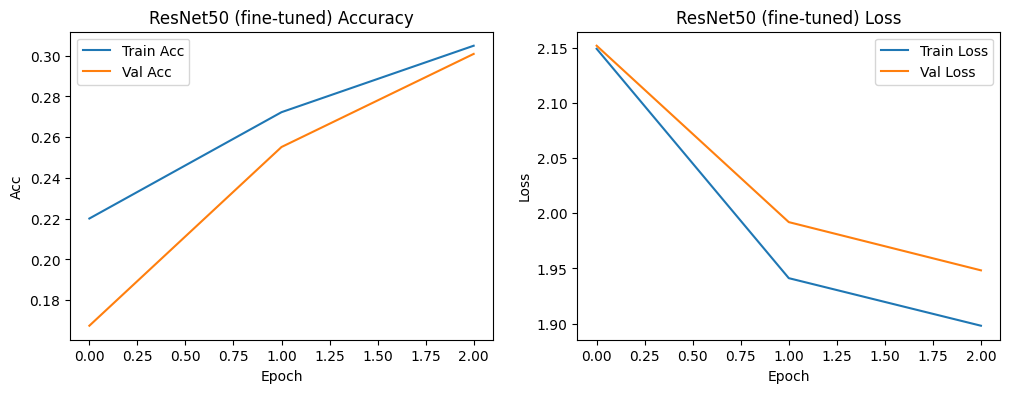

ResNet50 (fine-tuned) — Val Accuracy: 29.78% | Val Loss: 1.9425


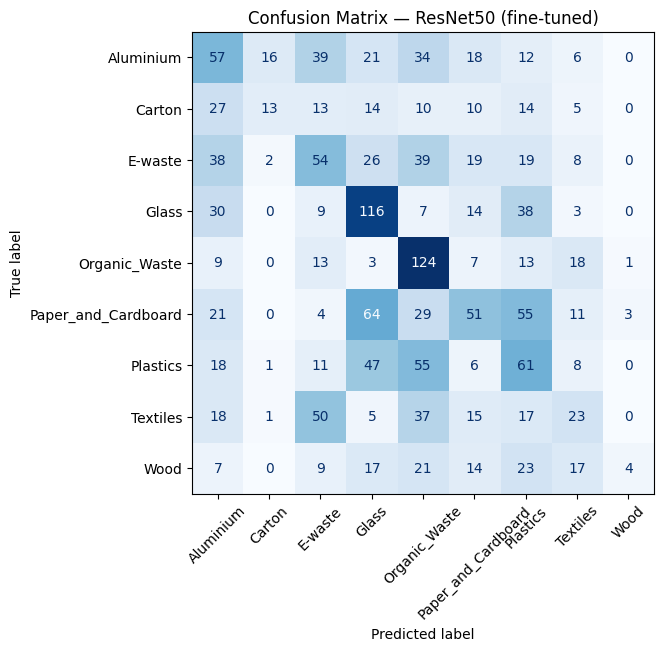

                     precision    recall  f1-score   support

          Aluminium       0.25      0.28      0.27       203
             Carton       0.39      0.12      0.19       106
            E-waste       0.27      0.26      0.27       205
              Glass       0.37      0.53      0.44       217
      Organic_Waste       0.35      0.66      0.46       188
Paper_and_Cardboard       0.33      0.21      0.26       238
           Plastics       0.24      0.29      0.27       207
           Textiles       0.23      0.14      0.17       166
               Wood       0.50      0.04      0.07       112

           accuracy                           0.31      1642
          macro avg       0.33      0.28      0.26      1642
       weighted avg       0.32      0.31      0.28      1642



In [18]:
# STEP 10 — Fine-tune last layers
UNFREEZE_LAST = 20
for layer in base_resnet.layers[-UNFREEZE_LAST:]:
    layer.trainable = True
resnet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
hist_resnet_ft = resnet_model.fit(train_aug, validation_data=val_aug, epochs=3,
                                  callbacks=common_callbacks('resnet50_finetune'), verbose=1)
plot_history(hist_resnet_ft, "ResNet50 (fine-tuned)")
eval_and_report(resnet_model, val_aug, "ResNet50 (fine-tuned)")

In [26]:
# STEP 11 — Save all models for team compare
save_root = '/content/drive/MyDrive/Waste_Images'
baseline.save(os.path.join(save_root, 'model_baseline_cnn.keras'))
aug_cnn.save(os.path.join(save_root, 'model_augmented_cnn.keras'))
mnet.save(os.path.join(save_root, 'model_mobilenetv2.keras'))
resnet_model.save(os.path.join(save_root, 'model_resnet50.keras'))
print("Saved all trained models to Google Drive.")

Saved all trained models to Google Drive.


In [27]:

# STEP 12 — Quick comparison table (val acc)
def best_val_acc(h): return float(np.max(h.history['val_accuracy']))
summary = {
    "Baseline CNN": best_val_acc(hist_base),
    "Augmented CNN": best_val_acc(hist_aug),
    "MobileNetV2 (frozen)": best_val_acc(hist_mnet),
    "MobileNetV2 (fine-tuned)": best_val_acc(hist_ft),
    "ResNet50 (frozen)": best_val_acc(hist_resnet),
    "ResNet50 (fine-tuned)": best_val_acc(hist_resnet_ft)
}
print("\n📈 Validation Accuracy Summary:")
for k,v in summary.items():
    print(f"{k:30s}: {v:.4f}")



📈 Validation Accuracy Summary:
Baseline CNN                  : 0.4415
Augmented CNN                 : 0.4019
MobileNetV2 (frozen)          : 0.8039
MobileNetV2 (fine-tuned)      : 0.7972
ResNet50 (frozen)             : 0.2192
ResNet50 (fine-tuned)         : 0.3009
